In [ ]:
import numpy as np
import pandas as pd
import warnings
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.gaussian_process import GaussianProcessRegressor, GaussianProcessClassifier
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error, confusion_matrix, classification_report

import mpltern  

# Matminer imports
from matminer.featurizers.composition import ElementProperty, Stoichiometry, ValenceOrbital, IonProperty, WenAlloys
from pymatgen.core import Composition

## Dataset and Feature Construction

In [2]:
df_features21 = pd.read_csv('GPR_Features_21.csv')
#drop composition column
df_features21 = df_features21.drop(columns=['composition'])
df_features21

,Ni (wt %),Co (wt %),Cr (wt %),Hot Cracking,Have,dT/d(sqrt(fs),BCC_B2,FCC_L12,MagpieData mean Number,MagpieData mean AtomicWeight,MagpieData mean MeltingT,MagpieData mean CovalentRadius,MagpieData mean Electronegativity,MagpieData mean NsValence,2-norm,avg d valence electrons,Configuration entropy,Miedema_deltaH_inter,Miedema_deltaH_amor,Miedema_deltaH_ss_min
0,74.11,8.23,17.66,0,197.660,16.836723,0.000000,1.000000,27.140000,57.406610,1819.340000,127.085000,1.858850,1.805000,0.755017,7.335000,-0.006269,-0.066884,0.003661,-0.087992
1,67.10,7.46,25.45,0,223.700,35.444043,0.000000,1.000000,26.816000,56.848816,1856.536000,128.314000,1.838340,1.722000,0.710611,7.094000,-0.006862,-0.086355,-0.011566,-0.108067
2,60.09,6.68,33.24,0,229.240,62.551336,0.000000,1.000000,26.496000,56.297719,1893.280000,129.528000,1.818080,1.640000,0.682255,6.856000,-0.007162,-0.100546,-0.021773,-0.119173
3,53.08,5.90,41.03,0,224.420,55.044612,0.001545,0.998455,26.184000,55.760017,1929.120000,130.712000,1.798320,1.560000,0.671381,6.624000,-0.007216,-0.107231,-0.025767,-0.110374
4,46.07,5.12,48.82,0,326.620,11.025638,0.293112,0.706888,25.876000,55.229011,1964.508000,131.881000,1.778810,1.481000,0.677609,6.395000,-0.007055,-0.105765,-0.023333,-0.092606
5,39.06,4.34,56.60,1,488.240,48.990026,0.691212,0.308788,25.576000,54.711401,1998.992000,133.020000,1.759800,1.404000,0.699508,6.172000,-0.006693,-0.096925,-0.015132,-0.064290
6,32.05,3.56,64.39,1,628.410,162.711279,0.831143,0.168857,25.283000,54.207425,2032.612000,134.131000,1.741260,1.329000,0.734129,5.954000,-0.006158,-0.082655,-0.002542,-0.057694
7,25.04,2.78,72.18,1,698.465,315.898171,0.889750,0.110250,24.991000,53.703209,2066.192000,135.240000,1.722750,1.254000,0.780757,5.737000,-0.005391,-0.064904,0.013276,-0.048511
8,18.03,2.00,79.97,1,768.560,496.830932,0.940310,0.059690,24.706707,53.213845,2098.826827,136.318318,1.704755,1.181181,0.835111,5.525526,-0.004422,-0.046223,0.030510,-0.037295
9,40.91,40.91,18.18,0,159.000,20.468201,0.000000,1.000000,26.797000,57.442921,1834.812000,127.813000,1.847780,1.799000,0.599668,6.998000,-0.008776,-0.089053,-0.013345,-0.096944


In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from pymatgen.core import Composition
from matminer.featurizers.composition import (
    ElementProperty, Stoichiometry, ValenceOrbital, IonProperty, WenAlloys, Miedema
)
import warnings

warnings.filterwarnings("ignore")

###############################################################################
# CANDIDATE POOL GENERATION & RE-FEATURIZATION WITH MATMINER
###############################################################################

# Load featurized training data 
df_train = df_features21.copy()  

# Define features and targets
target_obj = "Have"              # target property to maximize
constraint_col = "Hot Cracking"  # optional constraint

# Features used for training (exclude targets and identifiers)
training_features = [
    col for col in df_train.columns if col not in [target_obj, constraint_col, "composition"]
]
print("Training features used:", training_features)

# Prepare training data for clustering and scaling
imputer = SimpleImputer(strategy="mean")
X = pd.DataFrame(imputer.fit_transform(df_train[training_features]), columns=training_features)
y = df_train[target_obj].values
c = df_train[constraint_col].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Training data shape:", X_scaled.shape)

# Define composition and experimental columns
composition_cols = ['Ni (wt %)', 'Co (wt %)', 'Cr (wt %)']
exp_cols = ["dT/d(sqrt(fs)", "BCC_B2", "FCC_L12"]

# Generate random candidate compositions 
n_candidates = 1000
candidate_compositions = np.random.dirichlet([1, 1, 1], n_candidates) * 100
df_candidates_comp = pd.DataFrame(candidate_compositions, columns=composition_cols)

# Use KMeans clustering to impute experimental features
train_comp = df_train[composition_cols].values
kmeans = KMeans(n_clusters=5, random_state=0)
train_clusters = kmeans.fit_predict(train_comp)
df_train['cluster'] = train_clusters

cand_comp = df_candidates_comp.values
candidate_clusters = kmeans.predict(cand_comp)

# Compute cluster means for experimental features
imputed_experiments = {}
for col in exp_cols:
    cluster_means = df_train.groupby('cluster')[col].mean().to_dict()
    imputed_experiments[col] = [cluster_means[cluster] for cluster in candidate_clusters]
df_candidates_exp = pd.DataFrame(imputed_experiments)

# Convert wt% to composition strings (NiXCoYCrZ)
atomic_weights = {'Ni': 58.6934, 'Co': 58.933, 'Cr': 51.9961}

def convert_to_composition(row):
    moles = {el: row[el] / atomic_weights[el.split()[0]] for el in composition_cols}
    total_moles = sum(moles.values())
    atomic_fractions = {el: moles[el] / total_moles for el in moles}
    return ''.join(f"{el.split()[0]}{atomic_fractions[el]:.3f}" for el in composition_cols)

df_candidates_raw = pd.concat([df_candidates_comp, df_candidates_exp], axis=1)
df_candidates_raw['composition'] = df_candidates_raw.apply(convert_to_composition, axis=1)
df_candidates_raw['composition'] = df_candidates_raw['composition'].apply(Composition)

# Re-featurize candidate compositions using same featurizers as training
featurizers = [
    ElementProperty.from_preset("magpie"),
    Stoichiometry(),
    ValenceOrbital(),
    IonProperty(impute_nan=True),
    WenAlloys(impute_nan=True),
    Miedema()
]

for featurizer in featurizers:
    df_candidates_raw = featurizer.featurize_dataframe(df_candidates_raw, "composition", ignore_errors=True)

# Keep only training features (drop extras)
df_candidates_featurized = df_candidates_raw.reindex(columns=training_features, fill_value=0)
print("Candidate pool shape after filtering to training features:", df_candidates_featurized.shape)

# Impute missing values and scale candidate features
df_candidates_featurized = pd.DataFrame(
    imputer.transform(df_candidates_featurized),
    columns=training_features
)

X_candidates_orig = df_candidates_featurized.values
X_candidates = scaler.transform(X_candidates_orig)
print("Scaled candidate pool shape:", X_candidates.shape)


Training features used: ['Ni (wt %)', 'Co (wt %)', 'Cr (wt %)', 'dT/d(sqrt(fs)', 'BCC_B2', 'FCC_L12', 'MagpieData mean Number', 'MagpieData mean AtomicWeight', 'MagpieData mean MeltingT', 'MagpieData mean CovalentRadius', 'MagpieData mean Electronegativity', 'MagpieData mean NsValence', '2-norm', 'avg d valence electrons', 'Configuration entropy', 'Miedema_deltaH_inter', 'Miedema_deltaH_amor', 'Miedema_deltaH_ss_min']
Training data shape: (27, 18)


ElementProperty:   0%|          | 0/1000 [00:00<?, ?it/s]

Stoichiometry:   0%|          | 0/1000 [00:00<?, ?it/s]

ValenceOrbital:   0%|          | 0/1000 [00:00<?, ?it/s]

IonProperty:   0%|          | 0/1000 [00:00<?, ?it/s]

WenAlloys:   0%|          | 0/1000 [00:00<?, ?it/s]

Miedema:   0%|          | 0/1000 [00:00<?, ?it/s]

Candidate pool shape after filtering to training features: (1000, 18)
Scaled candidate pool shape: (1000, 18)


## Machine Learning Models

In [4]:
import warnings
warnings.filterwarnings("ignore")

/opt/anaconda3/envs/MCF/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/envs/MCF/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/envs/MCF/lib/python3.11/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/opt/anaconda3/envs/MCF/lib/python3.11/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than 

Best hyperparameters for GP Regressor: {'kernel__k1__k1__constant_value': 0.1, 'kernel__k1__k2__length_scale': 0.1, 'kernel__k2__noise_level': 0.0001}

=== LOOCV Results ===
R² = 0.9512
MSE = 2714.2927 ± 3237.2413


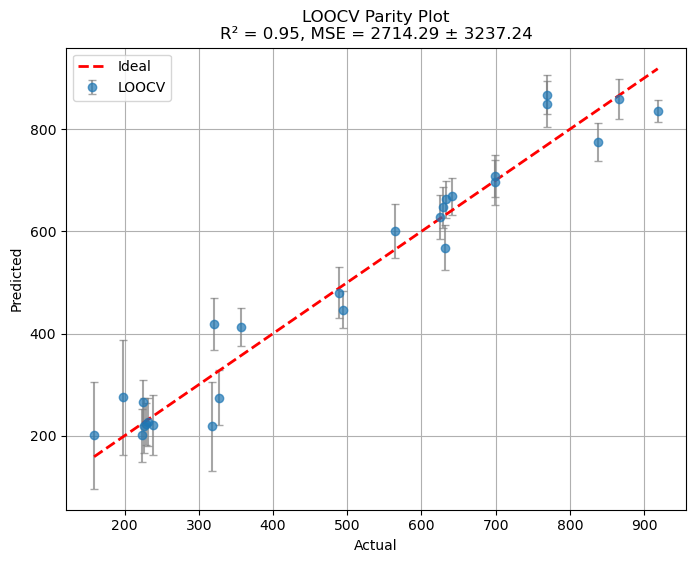

In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Hyperparameter tuning with LOOCV
kernel = ConstantKernel(1.0, (0.1, 10)) * RBF(1.0, (0.1, 10)) + WhiteKernel(1e-3, (1e-4, 1e-2))
param_grid = {
    "kernel__k1__k1__constant_value": [0.1, 1, 10],
    "kernel__k1__k2__length_scale": [0.1, 1, 10],
    "kernel__k2__noise_level": [1e-4, 1e-3, 1e-2]
}
gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=5, random_state=0)
grid_search = GridSearchCV(gpr, param_grid=param_grid, cv=LeaveOneOut(), scoring="r2", n_jobs=-1)
grid_search.fit(X_scaled, y)
best_gpr = grid_search.best_estimator_
print("Best hyperparameters for GP Regressor:", grid_search.best_params_)

# LOOCV Evaluation
loo = LeaveOneOut()
y_pred_loocv, y_std_loocv, mse_loocv = [], [], []

for train_idx, test_idx in loo.split(X_scaled):
    gp = GaussianProcessRegressor(kernel=best_gpr.kernel_, normalize_y=True, n_restarts_optimizer=5, random_state=0)
    gp.fit(X_scaled[train_idx], y[train_idx])
    y_pred, y_std = gp.predict(X_scaled[test_idx], return_std=True)
    y_pred_loocv.append(y_pred[0])
    y_std_loocv.append(y_std[0])
    mse_loocv.append((y[test_idx][0] - y_pred[0]) ** 2)

r2_loocv = r2_score(y, y_pred_loocv)
mse_loocv_mean = mean_squared_error(y, y_pred_loocv)
mse_loocv_std = np.std(mse_loocv)

# Results Summary
print("\n=== LOOCV Results ===")
print(f"R² = {r2_loocv:.4f}")
print(f"MSE = {mse_loocv_mean:.4f} ± {mse_loocv_std:.4f}")

# Parity Plot
plt.figure(figsize=(8, 6))
plt.errorbar(y, y_pred_loocv, yerr=y_std_loocv, fmt='o', ecolor='gray', capsize=3, alpha=0.7, label="LOOCV")
plt.plot([min(y), max(y)], [min(y), max(y)], 'r--', lw=2, label="Ideal")
plt.title(f"LOOCV Parity Plot\nR² = {r2_loocv:.2f}, MSE = {mse_loocv_mean:.2f} ± {mse_loocv_std:.2f}")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.grid(True)
plt.show()



=== LOOCV Results (Classification) ===
Confusion Matrix:
 [[11  1]
 [ 2 13]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.92      0.88        12
           1       0.93      0.87      0.90        15

    accuracy                           0.89        27
   macro avg       0.89      0.89      0.89        27
weighted avg       0.89      0.89      0.89        27



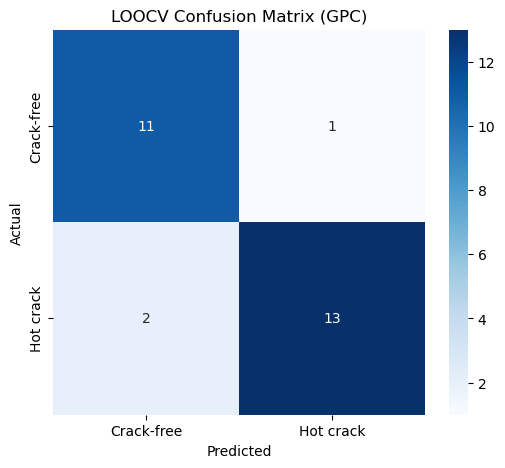

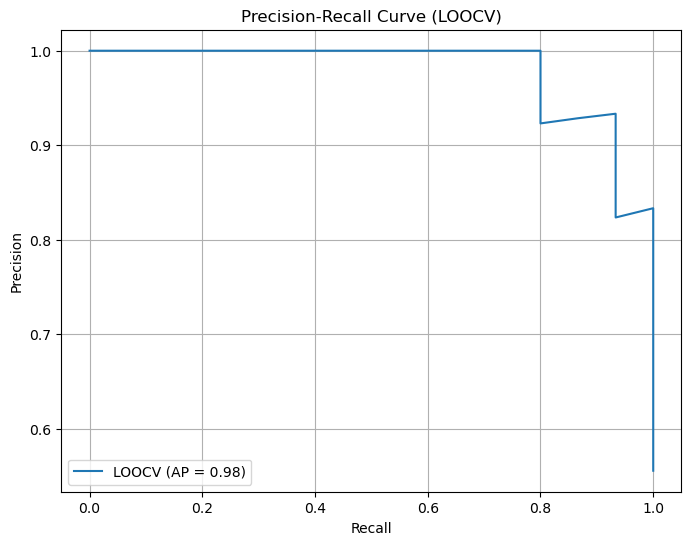

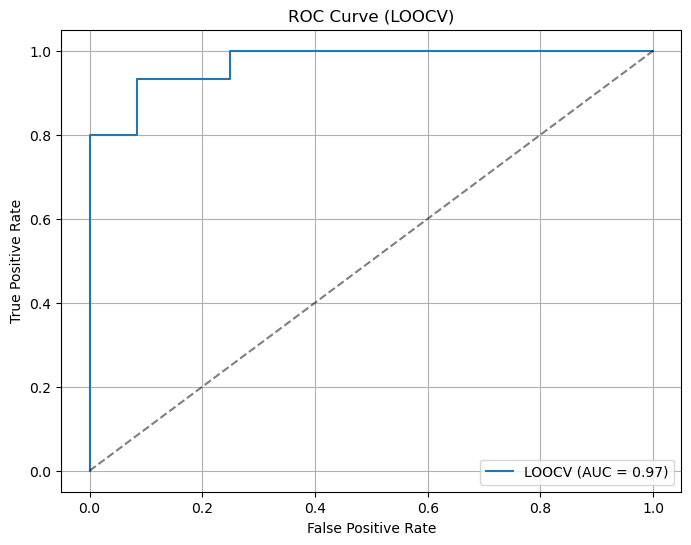

In [ ]:
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, average_precision_score, roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Hyperparameter Tuning with LOOCV for GPC
kernel_clf = 1.0 * RBF(length_scale=1.0)
gpc = GaussianProcessClassifier(kernel=kernel_clf, n_restarts_optimizer=5, random_state=0)

param_grid_clf = {
    "kernel__k1__constant_value": [0.1, 1, 10],
    "kernel__k2__length_scale": [0.1, 1, 10]
}

grid_search_clf = GridSearchCV(gpc, param_grid=param_grid_clf, cv=LeaveOneOut(), scoring="accuracy", n_jobs=-1)
grid_search_clf.fit(X_scaled, c)
best_gpc = grid_search_clf.best_estimator_

# LOOCV Evaluation for Classification
c_pred_loocv, proba_loocv, true_loocv = [], [], []
loo = LeaveOneOut()

for train_idx, test_idx in loo.split(X_scaled):
    model = GaussianProcessClassifier(kernel=best_gpc.kernel_, n_restarts_optimizer=5, random_state=0)
    model.fit(X_scaled[train_idx], c[train_idx])
    prob = model.predict_proba(X_scaled[test_idx])[0][1]
    pred = model.predict(X_scaled[test_idx])
    c_pred_loocv.append(pred[0])
    proba_loocv.append(prob)
    true_loocv.append(c[test_idx][0])

cm_loocv = confusion_matrix(c, c_pred_loocv)

# Precision-Recall and ROC Curves (LOOCV)
precision_loocv, recall_loocv, _ = precision_recall_curve(true_loocv, proba_loocv)
ap_loocv = average_precision_score(true_loocv, proba_loocv)
fpr_loocv, tpr_loocv, _ = roc_curve(true_loocv, proba_loocv)
roc_auc_loocv = auc(fpr_loocv, tpr_loocv)

# Results Summary
print("\n=== LOOCV Results (Classification) ===")
print("Confusion Matrix:\n", cm_loocv)
print("Classification Report:\n", classification_report(c, c_pred_loocv))

# Visualization
plt.figure(figsize=(6, 5))
sns.heatmap(cm_loocv, annot=True, fmt="d", cmap="Blues", xticklabels=["Crack-free", "Hot crack"], yticklabels=["Crack-free", "Hot crack"])
plt.title("LOOCV Confusion Matrix (GPC)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(recall_loocv, precision_loocv, label=f"LOOCV (AP = {ap_loocv:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (LOOCV)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(fpr_loocv, tpr_loocv, label=f"LOOCV (AUC = {roc_auc_loocv:.2f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (LOOCV)")
plt.legend()
plt.grid(True)
plt.show()

## Acquisition Strategy

### CEI-Based Candidate Selection

In [ ]:
# Inspect p_safe distribution over the entire candidate pool.
p_safe_pool = gp_clf.predict_proba(X_pool)[:, 0]  # Probability that Hot Cracking = 0
print("=== p_safe Distribution Summary ===")
print("Min p_safe:", np.min(p_safe_pool))
print("Max p_safe:", np.max(p_safe_pool))
print("Mean p_safe:", np.mean(p_safe_pool))
print(f"Number of candidates with p_safe >= 0.75: {np.sum(p_safe_pool >= 0.75)}")
print(f"Number of candidates with p_safe >= 0.85: {np.sum(p_safe_pool >= 0.85)}")
print(f"Number of candidates with p_safe >= 0.90: {np.sum(p_safe_pool >= 0.90)}")


=== p_safe Distribution Summary ===
Min p_safe: 0.12195733282374022
Max p_safe: 0.8656060754788086
Mean p_safe: 0.6091756751988401
Number of candidates with p_safe >= 0.75: 376
Number of candidates with p_safe >= 0.85: 21
Number of candidates with p_safe >= 0.90: 0


CEI Selection with 85% Safety Threshold

Best observed safe hardness: 357.0
Selected Candidate Alloys (original scale):
   Ni (wt %)  Co (wt %)  Cr (wt %)  dT/d(sqrt(fs)    BCC_B2   FCC_L12  \
0  10.705423  68.776332  20.518245      31.432326  0.077518  0.922482   
1  14.284384  67.070912  18.644704      31.432326  0.077518  0.922482   
2  13.457138  68.526285  18.016577      31.432326  0.077518  0.922482   
3  11.422153  70.614782  17.963065      31.432326  0.077518  0.922482   
4  48.711928  14.885426  36.402646      38.315396  0.164312  0.835688   

   MagpieData mean Number  MagpieData mean AtomicWeight  \
0               26.427000                     57.340233   
1               26.522000                     57.470582   
2               26.535000                     57.521060   
3               26.515000                     57.525856   
4               26.287712                     56.098007   

   MagpieData mean MeltingT  MagpieData mean CovalentRadius  \
0               1856.912000                      128.728000   
1

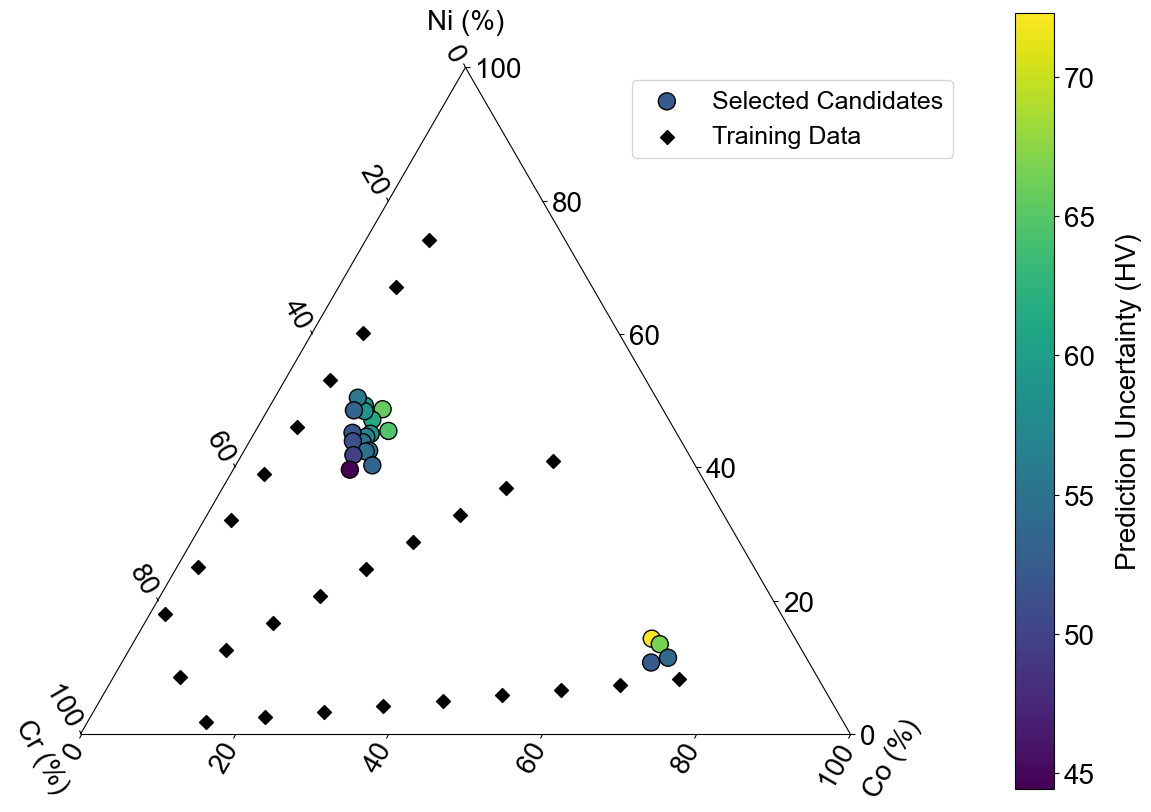


=== Additional Evaluation Factors ===
Best Value: 290.3463
Average Value: 206.6641
Exploration Ratio: 1.0000


In [ ]:
# ACQUISITION FUNCTION & SELECTION OF NEW CANDIDATES
safe_indices = np.where(c == 0)[0]
if len(safe_indices) > 0:
    f_best = np.max(y[safe_indices])
else:
    f_best = np.max(y)
print("Best observed safe hardness:", f_best)  

def compute_ei(mu, sigma, f_best):
    sigma = np.maximum(sigma, 1e-9)
    improvement = mu - f_best
    z = improvement / sigma
    ei = improvement * norm.cdf(z) + sigma * norm.pdf(z)
    return ei

def compute_cei_entropy(X_candidates, gp_reg, gp_clf, f_best, p_threshold=0.80):
    # Predict hardness mean and uncertainty for all candidates.
    mu, sigma = gp_reg.predict(X_candidates, return_std=True)
    sigma = np.maximum(sigma, 1e-9)
    # Compute Expected Improvement (EI)
    ei = compute_ei(mu, sigma, f_best)
    # Get the safe probability from the classifier (assumes class 0 = safe)
    p_safe = gp_clf.predict_proba(X_candidates)[:, 0]
    
    # Initialize acquisition values with -infinity.
    cei = -np.inf * np.ones_like(ei)
    
    # Create mask for candidates that pass the safety threshold.
    safe_mask = p_safe >= p_threshold
    #safe_mask= np.array(p_safe)
    
    if np.any(safe_mask):
        # For candidates meeting the threshold, compute binary entropy.
        epsilon = 1e-9  # Avoid log(0)
        H = -p_safe[safe_mask] * np.log(p_safe[safe_mask] + epsilon) \
            - (1 - p_safe[safe_mask]) * np.log(1 - p_safe[safe_mask] + epsilon)
        H_norm = H / np.log(2)  # Normalize entropy to [0,1]
        safe_factor = 1 - H_norm  # Higher factor for lower uncertainty
        
        # Compute constrained acquisition values only for safe candidates.
        cei[safe_mask] = ei[safe_mask]
    return cei

selected_candidates_scaled = []
selected_indices = []

# Define gp_reg, gp_clf, and f_best
gp_reg = best_gpr
gp_clf = best_gpc # Assuming the best observed value is the maximum of the target values

X_pool = X_candidates.copy()
df_pool = df_candidates_featurized.copy()

# Compute CEI for all candidates in X_pool at once.
cei_values_all = compute_cei_entropy(X_pool, gp_reg, gp_clf, f_best, p_threshold=0.85)

# Select indices of the top 9 candidates (highest CEI)
batch_size =np.sum(p_safe_pool >= 0.85) 
top_indices = np.argsort(cei_values_all)[-batch_size:]
top_indices = top_indices[np.argsort(cei_values_all[top_indices])[::-1]]

# Select the corresponding candidate feature vectors and indices.
selected_candidates_scaled = X_pool[top_indices]
selected_indices = df_pool.index[top_indices]

# Inverse transform the selected candidate feature vectors back to original scale.
selected_candidates_orig = scaler.inverse_transform(selected_candidates_scaled)
selected_df = pd.DataFrame(selected_candidates_orig, columns=df_candidates_featurized.columns)

# Include the corresponding CEI values as a new column in the DataFrame.
selected_df["CEI"] = cei_values_all[top_indices]

print("Selected Candidate Alloys (original scale):")
print(selected_df.head())

# EVALUATE SELECTED CANDIDATES & TERNARY PLOT
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'

X_selected = scaler.transform(selected_candidates_orig)
mu_sel, sigma_sel = gp_reg.predict(X_selected, return_std=True)
p_safe_sel = gp_clf.predict_proba(X_selected)[:, 0]

selected_df["Predicted_Have"] = mu_sel
selected_df["Uncertainty"] = sigma_sel
selected_df["P_safe"] = p_safe_sel

print("\nSelected Candidate Alloys with Predictions:")
print(selected_df.head())

Ni = selected_df["Ni (wt %)"].values
Co = selected_df["Co (wt %)"].values
Cr = selected_df["Cr (wt %)"].values
sum_comp = Ni + Co + Cr
Ni_norm = 100 * Ni / sum_comp
Co_norm = 100 * Co / sum_comp
Cr_norm = 100 * Cr / sum_comp

# Compute normalized candidate compositions
# For the training data, extract and normalize the composition columns.
Ni_train = df_train["Ni (wt %)"].values
Co_train = df_train["Co (wt %)"].values
Cr_train = df_train["Cr (wt %)"].values
sum_train = Ni_train + Co_train + Cr_train
Ni_train_norm = 100 * Ni_train / sum_train
Co_train_norm = 100 * Co_train / sum_train
Cr_train_norm = 100 * Cr_train / sum_train

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(1, 1, 1, projection="ternary", ternary_sum=100.0)

# Plot the selected candidate alloys.
sc = ax.scatter(Ni_norm, Cr_norm, Co_norm, c=sigma_sel, cmap="viridis",
                edgecolor="k", s=150, label="Selected Candidates")
cbar = plt.colorbar(sc, ax=ax, shrink=0.8, pad=0.15)
cbar.ax.tick_params(labelsize=20)
cbar.set_label("Prediction Uncertainty (HV)", fontsize=20, labelpad=15)

# Annotate each candidate with its predicted hardness, slightly offset from the point.
ax.scatter(Ni_train_norm, Cr_train_norm, Co_train_norm, 
           marker='D', color='black', s=50, label="Training Data")

ax.set_tlabel("Ni (%)", fontsize=20)
ax.set_rlabel("Co (%)", fontsize=20)
ax.set_llabel("Cr (%)", fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.legend(loc="upper right", fontsize=18, bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

# ADDITIONAL EVALUATION FACTORS
# Calculate scalar values directly without adding them as columns
best_value = selected_df["Predicted_Have"].max()
average_value = selected_df["Predicted_Have"].mean()
exploration_ratio = len(selected_df.drop_duplicates()) / len(selected_df)

# Print the evaluation factors
print("\n=== Additional Evaluation Factors ===")
print(f"Best Value: {best_value:.4f}")
print(f"Average Value: {average_value:.4f}")
print(f"Exploration Ratio: {exploration_ratio:.4f}")


CEI Selection with 75% Safety Threshold

Best observed safe hardness: 357.0
Selected Candidate Alloys (original scale):
   Ni (wt %)  Co (wt %)  Cr (wt %)  dT/d(sqrt(fs)    BCC_B2   FCC_L12  \
0  16.832023  74.385293   8.782684      31.432326  0.077518  0.922482   
1  10.459647  61.596791  27.943562      31.432326  0.077518  0.922482   
2  13.402752  56.269278  30.327970      31.432326  0.077518  0.922482   
3  11.969090  59.395810  28.635100      31.432326  0.077518  0.922482   
4  25.195481  66.295110   8.509409      31.432326  0.077518  0.922482   

   MagpieData mean Number  MagpieData mean AtomicWeight  \
0                  26.873                     58.213314   
1                  26.186                     56.793162   
2                  26.139                     56.613020   
3                  26.180                     56.741005   
4                  26.965                     58.214222   

   MagpieData mean MeltingT  MagpieData mean CovalentRadius  \
0                  1801.696                         126.940   
1

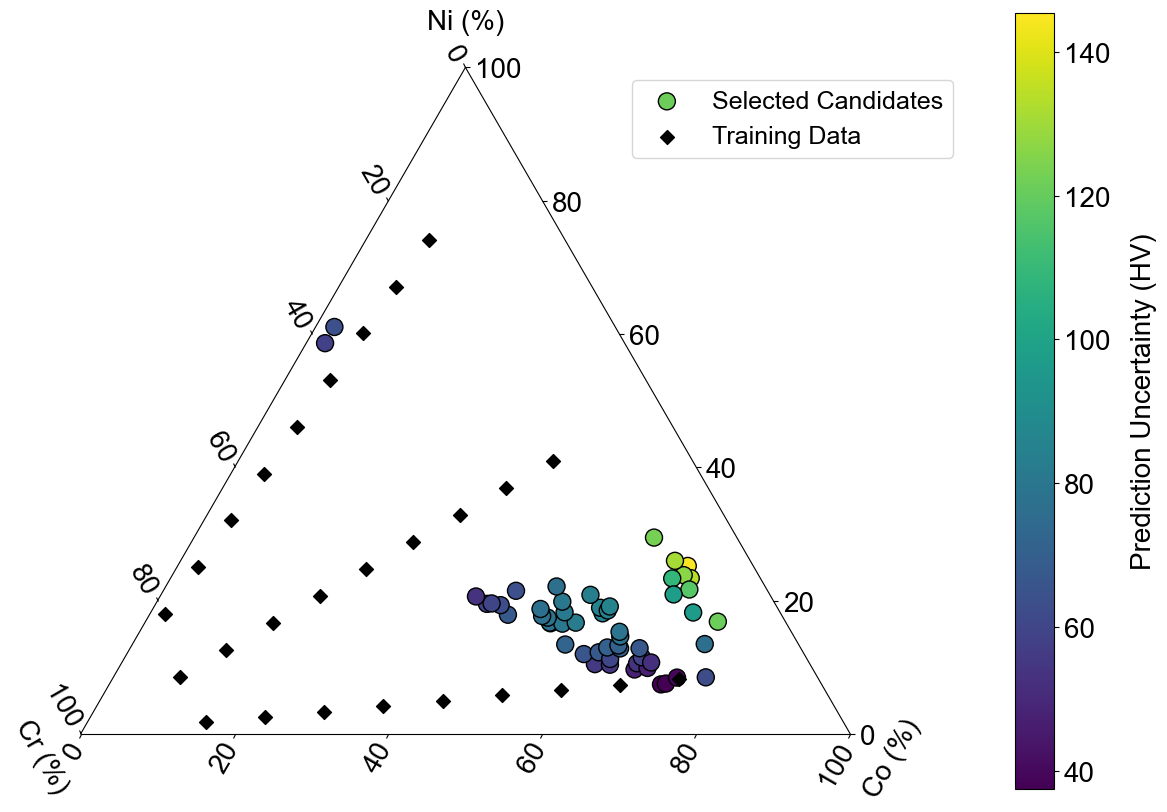

=== p_safe Distribution Summary ===
Min p_safe: 0.12195733282374022
Max p_safe: 0.8656060754788086
Mean p_safe: 0.6091756751988401
Number of candidates with p_safe >= 0.75: 376
Number of candidates with p_safe >= 0.85: 21
Number of candidates with p_safe >= 0.90: 0

=== Additional Evaluation Factors ===
Best Value: 355.2581
Average Value: 277.9024
Exploration Ratio: 1.0000


In [ ]:
# ACQUISITION FUNCTION & SELECTION OF NEW CANDIDATES
safe_indices = np.where(c == 0)[0]
if len(safe_indices) > 0:
    f_best = np.max(y[safe_indices])
else:
    f_best = np.max(y)
print("Best observed safe hardness:", f_best)  


def compute_ei(mu, sigma, f_best):
    sigma = np.maximum(sigma, 1e-9)
    improvement = mu - f_best
    z = improvement / sigma
    ei = improvement * norm.cdf(z) + sigma * norm.pdf(z)
    return ei

def compute_cei_entropy(X_candidates, gp_reg, gp_clf, f_best, p_threshold=0.85):
    # Predict hardness mean and uncertainty for all candidates.
    mu, sigma = gp_reg.predict(X_candidates, return_std=True)
    sigma = np.maximum(sigma, 1e-9)
    # Compute Expected Improvement (EI)
    ei = compute_ei(mu, sigma, f_best)
    # Get the safe probability from the classifier (assumes class 0 = safe)
    p_safe = gp_clf.predict_proba(X_candidates)[:, 0]
    
    # Initialize acquisition values with -infinity.
    cei = -np.inf * np.ones_like(ei)
    
    # Create mask for candidates that pass the safety threshold.
    safe_mask = p_safe >= p_threshold
    # safe_mask= np.array(p_safe)
    
    if np.any(safe_mask):
        # For candidates meeting the threshold, compute binary entropy.
        epsilon = 1e-9  # Avoid log(0)
        H = -p_safe[safe_mask] * np.log(p_safe[safe_mask] + epsilon) \
            - (1 - p_safe[safe_mask]) * np.log(1 - p_safe[safe_mask] + epsilon)
        H_norm = H / np.log(2)  # Normalize entropy to [0,1]
        safe_factor = 1 - H_norm  # Higher factor for lower uncertainty
        
        # Compute constrained acquisition values only for safe candidates.
        cei[safe_mask] = ei[safe_mask]
    return cei

selected_candidates_scaled = []
selected_indices = []

# Define gp_reg, gp_clf, and f_best
gp_reg = best_gpr
gp_clf = best_gpc # Assuming the best observed value is the maximum of the target values

X_pool = X_candidates.copy()
df_pool = df_candidates_featurized.copy()

# Compute CEI for all candidates in X_pool at once.
cei_values_all = compute_cei_entropy(X_pool, gp_reg, gp_clf, f_best, p_threshold=0.75)

# Select indices of the top 9 candidates (highest CEI)
batch_size = 55
top_indices = np.argsort(cei_values_all)[-batch_size:]
top_indices = top_indices[np.argsort(cei_values_all[top_indices])[::-1]]

# Select the corresponding candidate feature vectors and indices.
selected_candidates_scaled = X_pool[top_indices]
selected_indices = df_pool.index[top_indices]

# Inverse transform the selected candidate feature vectors back to original scale.
selected_candidates_orig = scaler.inverse_transform(selected_candidates_scaled)
selected_df = pd.DataFrame(selected_candidates_orig, columns=df_candidates_featurized.columns)

# Include the corresponding CEI values as a new column in the DataFrame.
selected_df["CEI"] = cei_values_all[top_indices]

print("Selected Candidate Alloys (original scale):")
print(selected_df.head())

# EVALUATE SELECTED CANDIDATES & TERNARY PLOT
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'

X_selected = scaler.transform(selected_candidates_orig)
mu_sel, sigma_sel = gp_reg.predict(X_selected, return_std=True)
p_safe_sel = gp_clf.predict_proba(X_selected)[:, 0]

selected_df["Predicted_Have"] = mu_sel
selected_df["Uncertainty"] = sigma_sel
selected_df["P_safe"] = p_safe_sel

print("\nSelected Candidate Alloys with Predictions:")
print(selected_df.head())

Ni = selected_df["Ni (wt %)"].values
Co = selected_df["Co (wt %)"].values
Cr = selected_df["Cr (wt %)"].values
sum_comp = Ni + Co + Cr
Ni_norm = 100 * Ni / sum_comp
Co_norm = 100 * Co / sum_comp
Cr_norm = 100 * Cr / sum_comp

# Compute normalized candidate compositions 
# For the training data, extract and normalize the composition columns.
Ni_train = df_train["Ni (wt %)"].values
Co_train = df_train["Co (wt %)"].values
Cr_train = df_train["Cr (wt %)"].values
sum_train = Ni_train + Co_train + Cr_train
Ni_train_norm = 100 * Ni_train / sum_train
Co_train_norm = 100 * Co_train / sum_train
Cr_train_norm = 100 * Cr_train / sum_train

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(1, 1, 1, projection="ternary", ternary_sum=100.0)

# Plot the selected candidate alloys.
sc = ax.scatter(Ni_norm, Cr_norm, Co_norm, c=sigma_sel, cmap="viridis",
                edgecolor="k", s=150, label="Selected Candidates")
cbar = plt.colorbar(sc, ax=ax, shrink=0.8, pad=0.15)
cbar.ax.tick_params(labelsize=20)
cbar.set_label("Prediction Uncertainty (HV)", fontsize=20, labelpad=15)

# Annotate each candidate with its predicted hardness.
ax.scatter(Ni_train_norm, Cr_train_norm, Co_train_norm, 
           marker='D', color='black', s=50, label="Training Data")

ax.set_tlabel("Ni (%)", fontsize=20)
ax.set_rlabel("Co (%)", fontsize=20)
ax.set_llabel("Cr (%)", fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.legend(loc="upper right", fontsize=18, bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

# Inspect p_safe distribution over the entire candidate pool.
p_safe_pool = gp_clf.predict_proba(X_pool)[:, 0]  # Probability that Hot Cracking = 0
print("=== p_safe Distribution Summary ===")
print("Min p_safe:", np.min(p_safe_pool))
print("Max p_safe:", np.max(p_safe_pool))
print("Mean p_safe:", np.mean(p_safe_pool))
print(f"Number of candidates with p_safe >= 0.75: {np.sum(p_safe_pool >= 0.75)}")
print(f"Number of candidates with p_safe >= 0.85: {np.sum(p_safe_pool >= 0.85)}")
print(f"Number of candidates with p_safe >= 0.90: {np.sum(p_safe_pool >= 0.90)}")

# ADDITIONAL EVALUATION FACTORS
# Calculate scalar values directly without adding them as columns
best_value = selected_df["Predicted_Have"].max()
average_value = selected_df["Predicted_Have"].mean()
exploration_ratio = len(selected_df.drop_duplicates()) / len(selected_df)

# Print the evaluation factors
print("\n=== Additional Evaluation Factors ===")
print(f"Best Value: {best_value:.4f}")
print(f"Average Value: {average_value:.4f}")
print(f"Exploration Ratio: {exploration_ratio:.4f}")


Visualization of Predicted Safety Probability

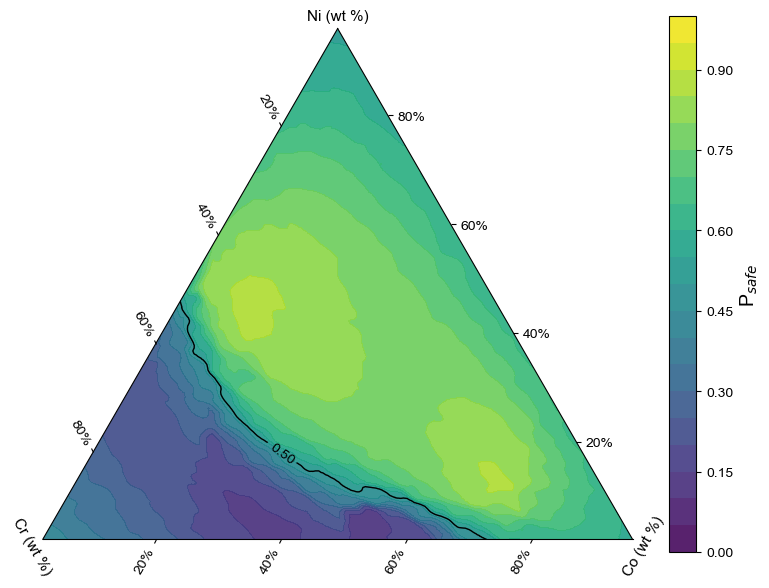

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mpltern
from matplotlib.ticker import PercentFormatter
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

from matplotlib import rcParams
rcParams['font.family'] = 'Arial'

p_safe = best_gpc.predict_proba(X_candidates)[:,0]
Co = df_candidates_comp['Ni (wt %)'].values
Cr = df_candidates_comp['Cr (wt %)'].values
Ni = df_candidates_comp['Co (wt %)'].values    

n_grid = 200
co_lin = np.linspace(0,100,n_grid)
cr_lin = np.linspace(0,100,n_grid)
Co_grid, Cr_grid = np.meshgrid(co_lin, cr_lin)
Ni_grid = 100 - Co_grid - Cr_grid
mask = (Ni_grid >= 0)

P_grid = griddata(
    (Co,Cr),
    p_safe,
    (Co_grid,Cr_grid),
    method='nearest'
)
P_grid[~mask] = np.nan

sigma = 1
P_smooth = gaussian_filter(P_grid, sigma=sigma, mode='nearest')
P_smooth[~mask] = np.nan

Co_extra = Co_grid[mask]
Cr_extra = Cr_grid[mask]
Ni_extra = Ni_grid[mask]
P_extra  = P_smooth[mask]

Co_all = np.concatenate([Co,      Co_extra])
Cr_all = np.concatenate([Cr,      Cr_extra])
Ni_all = np.concatenate([Ni,      Ni_extra])
P_all  = np.concatenate([p_safe,  P_extra ])

fig = plt.figure(figsize=(8,7))
ax  = fig.add_subplot(projection='ternary', ternary_sum=100)

ax.set_tlim(2, 98)
ax.set_llim(2, 98)
ax.set_rlim(2, 98)

finite_mask = np.isfinite(P_all)
Co_all = Co_all[finite_mask]
Cr_all = Cr_all[finite_mask]
Ni_all = Ni_all[finite_mask]
P_all = P_all[finite_mask]

cf = ax.tricontourf(
    Co_all, Cr_all, Ni_all,
    P_all,
    levels=np.linspace(0,1,21),
    cmap='viridis',
    alpha=0.9
)
cs = ax.tricontour(
    Co_all, Cr_all, Ni_all,
    P_all, levels=[0.5],
    colors='k', linewidths=1
)
ax.clabel(cs, fmt='%.2f', inline=True, fontsize=10)

cbar = fig.colorbar(cf, ax=ax, shrink=0.8)
cbar.set_label('P$_{safe}$', fontsize=14)

ax.set_tlabel('Ni (wt %)', fontsize=11)
ax.set_llabel('Cr (wt %)', fontsize=11)
ax.set_rlabel('Co (wt %)', fontsize=11)
for axis in (ax.taxis, ax.laxis, ax.raxis):
    axis.set_major_formatter(PercentFormatter(100))
    for lbl in axis.get_ticklabels():
        lbl.set_fontsize(10)

plt.tight_layout()
plt.show()


### CPI-Based Candidate Selection

In [ ]:
# Inspect p_safe distribution over the entire candidate pool.
p_safe_pool = gp_clf.predict_proba(X_pool)[:, 0]  # Probability that Hot Cracking = 0
print("=== p_safe Distribution Summary ===")
print("Min p_safe:", np.min(p_safe_pool))
print("Max p_safe:", np.max(p_safe_pool))
print("Mean p_safe:", np.mean(p_safe_pool))
print(f"Number of candidates with p_safe >= 0.75: {np.sum(p_safe_pool >= 0.75)}")
print(f"Number of candidates with p_safe >= 0.85: {np.sum(p_safe_pool >= 0.85)}")
print(f"Number of candidates with p_safe >= 0.90: {np.sum(p_safe_pool >= 0.90)}")

=== p_safe Distribution Summary ===
Min p_safe: 0.12195733282374022
Max p_safe: 0.8656060754788086
Mean p_safe: 0.6091756751988401
Number of candidates with p_safe >= 0.75: 376
Number of candidates with p_safe >= 0.85: 21
Number of candidates with p_safe >= 0.90: 0


CPI Selection with 85% Safety Threshold

Best observed safe hardness: 357.0
Selected Candidate Alloys (original scale):
   Ni (wt %)  Co (wt %)  Cr (wt %)  dT/d(sqrt(fs)    BCC_B2   FCC_L12  \
0  10.705423  68.776332  20.518245      31.432326  0.077518  0.922482   
1  11.422153  70.614782  17.963065      31.432326  0.077518  0.922482   
2  14.284384  67.070912  18.644704      31.432326  0.077518  0.922482   
3  13.457138  68.526285  18.016577      31.432326  0.077518  0.922482   
4  48.711928  14.885426  36.402646      38.315396  0.164312  0.835688   

   MagpieData mean Number  MagpieData mean AtomicWeight  \
0               26.427000                     57.340233   
1               26.515000                     57.525856   
2               26.522000                     57.470582   
3               26.535000                     57.521060   
4               26.287712                     56.098007   

   MagpieData mean MeltingT  MagpieData mean CovalentRadius  \
0               1856.912000                      128.728000   
1

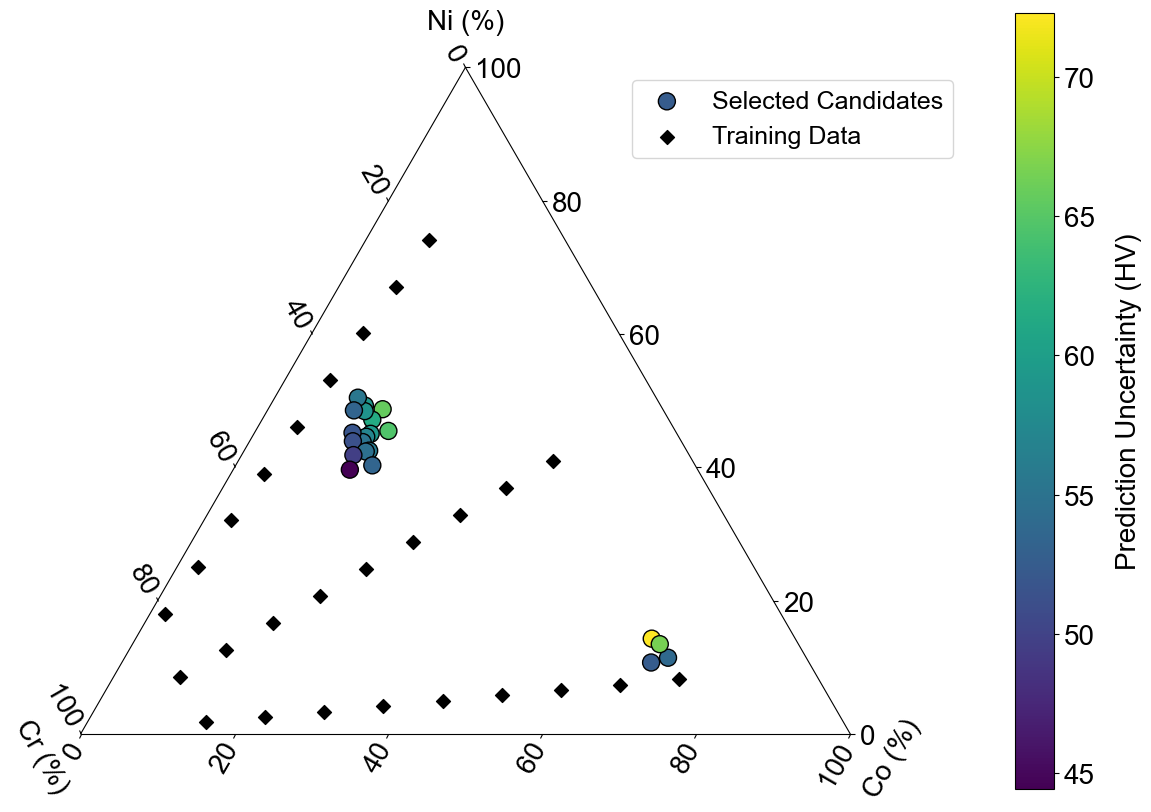


=== Additional Evaluation Factors ===
Best Value: 290.3463
Average Value: 206.6641
Exploration Ratio: 1.0000


In [ ]:
# ACQUISITION FUNCTION & SELECTION OF NEW CANDIDATES
safe_indices = np.where(c == 0)[0]
if len(safe_indices) > 0:
    f_best = np.max(y[safe_indices])
else:
    f_best = np.max(y)
print("Best observed safe hardness:", f_best) 

from scipy.stats import norm

def compute_cpi(X_candidates, gp_reg, gp_clf, f_best, p_threshold=0.85):
    """
    Compute Constrained Probability of Improvement (CPI) for candidate alloys.

    Args:
        X_candidates (array-like): Scaled candidate feature vectors.
        gp_reg (GaussianProcessRegressor): Trained GP regression model.
        gp_clf (GaussianProcessClassifier): Trained GP classification model.
        f_best (float): Best observed safe hardness value.
        p_threshold (float): Probability threshold for safety classification.

    Returns:
        cpi (array-like): CPI values for each candidate.
    """
    # Predict hardness mean and uncertainty for all candidates.
    mu, sigma = gp_reg.predict(X_candidates, return_std=True)
    sigma = np.maximum(sigma, 1e-9)  # Avoid division by zero

    # Compute Probability of Improvement (PI)
    z = (mu - f_best) / sigma
    pi = norm.cdf(z)

    # Get the safe probability from the classifier (assumes class 0 = safe)
    p_safe = gp_clf.predict_proba(X_candidates)[:, 0]

    # Initialize CPI values as zeros
    cpi = np.zeros_like(pi)
    
    # Create mask for candidates that pass the safety threshold.
    safe_mask = p_safe >= p_threshold
    cpi[safe_mask] = pi[safe_mask] * p_safe[safe_mask]

    return cpi


selected_candidates_scaled = []
selected_indices = []

# Define gp_reg, gp_clf, and f_best
gp_reg = best_gpr
gp_clf = best_gpc # Assuming the best observed value is the maximum of the target values

X_pool = X_candidates.copy()
df_pool = df_candidates_featurized.copy()

cpi_values_all = compute_cpi(X_pool, gp_reg, gp_clf, f_best, p_threshold=0.85)

batch_size = np.sum(p_safe_pool >= 0.85)
top_indices = np.argsort(cpi_values_all)[-batch_size:]
top_indices = top_indices[np.argsort(cpi_values_all[top_indices])[::-1]]

# Select the corresponding candidate feature vectors and indices.
selected_candidates_scaled = X_pool[top_indices]
selected_indices = df_pool.index[top_indices]

# Inverse transform the selected candidate feature vectors back to original scale.
selected_candidates_orig = scaler.inverse_transform(selected_candidates_scaled)
selected_df = pd.DataFrame(selected_candidates_orig, columns=df_candidates_featurized.columns)

# Include the corresponding CPI values as a new column in the DataFrame.
selected_df["CPI"] = cpi_values_all[top_indices]

print("Selected Candidate Alloys (original scale):")
print(selected_df.head())

# EVALUATE SELECTED CANDIDATES & TERNARY PLOT
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
X_selected = scaler.transform(selected_candidates_orig)
mu_sel, sigma_sel = gp_reg.predict(X_selected, return_std=True)
p_safe_sel = gp_clf.predict_proba(X_selected)[:, 0]

selected_df["Predicted_Have"] = mu_sel
selected_df["Uncertainty"] = sigma_sel
selected_df["P_safe"] = p_safe_sel

print("\nSelected Candidate Alloys with Predictions:")
print(selected_df.head())

Ni = selected_df["Ni (wt %)"].values
Co = selected_df["Co (wt %)"].values
Cr = selected_df["Cr (wt %)"].values
sum_comp = Ni + Co + Cr
Ni_norm = 100 * Ni / sum_comp
Co_norm = 100 * Co / sum_comp
Cr_norm = 100 * Cr / sum_comp

# Compute normalized candidate compositions 
# For the training data, extract and normalize the composition columns.
Ni_train = df_train["Ni (wt %)"].values
Co_train = df_train["Co (wt %)"].values
Cr_train = df_train["Cr (wt %)"].values
sum_train = Ni_train + Co_train + Cr_train
Ni_train_norm = 100 * Ni_train / sum_train
Co_train_norm = 100 * Co_train / sum_train
Cr_train_norm = 100 * Cr_train / sum_train

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(1, 1, 1, projection="ternary", ternary_sum=100.0)

# Plot the selected candidate alloys.
sc = ax.scatter(Ni_norm, Cr_norm, Co_norm, c=sigma_sel, cmap="viridis",
                edgecolor="k", s=150, label="Selected Candidates")
cbar = plt.colorbar(sc, ax=ax, shrink=0.8, pad=0.15)
cbar.ax.tick_params(labelsize=20)
cbar.set_label("Prediction Uncertainty (HV)", fontsize=20, labelpad=15)

# Annotate each candidate with its predicted hardness.
ax.scatter(Ni_train_norm, Cr_train_norm, Co_train_norm, 
           marker='D', color='black', s=50, label="Training Data")

ax.set_tlabel("Ni (%)", fontsize=20)
ax.set_rlabel("Co (%)", fontsize=20)
ax.set_llabel("Cr (%)", fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.legend(loc="upper right", fontsize=18, bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

# ADDITIONAL EVALUATION FACTORS
# Calculate scalar values directly without adding them as columns
best_value = selected_df["Predicted_Have"].max()
average_value = selected_df["Predicted_Have"].mean()
exploration_ratio = len(selected_df.drop_duplicates()) / len(selected_df)

# Print the evaluation factors
print("\n=== Additional Evaluation Factors ===")
print(f"Best Value: {best_value:.4f}")
print(f"Average Value: {average_value:.4f}")
print(f"Exploration Ratio: {exploration_ratio:.4f}")

CPI Selection with 75% Safety Threshold

Best observed safe hardness: 357.0
Selected Candidate Alloys (original scale):
   Ni (wt %)  Co (wt %)  Cr (wt %)  dT/d(sqrt(fs)    BCC_B2   FCC_L12  \
0  10.459647  61.596791  27.943562      31.432326  0.077518  0.922482   
1  11.969090  59.395810  28.635100      31.432326  0.077518  0.922482   
2  13.402752  56.269278  30.327970      31.432326  0.077518  0.922482   
3  10.373161  63.592909  26.033930      31.432326  0.077518  0.922482   
4   8.480449  76.995410  14.524141      31.432326  0.077518  0.922482   

   MagpieData mean Number  MagpieData mean AtomicWeight  \
0                  26.186                     56.793162   
1                  26.180                     56.741005   
2                  26.139                     56.613020   
3                  26.246                     56.931904   
4                  26.601                     57.796180   

   MagpieData mean MeltingT  MagpieData mean CovalentRadius  \
0                  1889.620                         129.763   
1

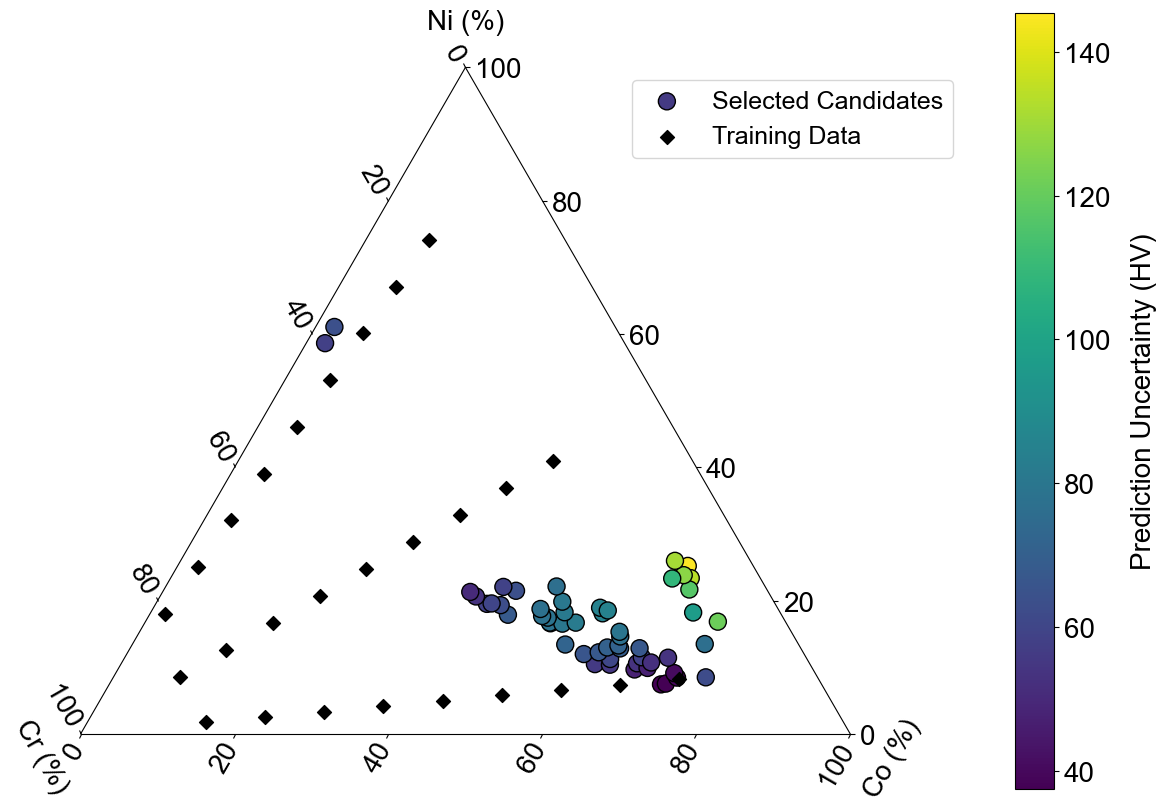


=== Additional Evaluation Factors ===
Best Value: 355.2581
Average Value: 283.6148
Exploration Ratio: 1.0000


In [ ]:
# ACQUISITION FUNCTION & SELECTION OF NEW CANDIDATES
safe_indices = np.where(c == 0)[0]
if len(safe_indices) > 0:
    f_best = np.max(y[safe_indices])
else:
    f_best = np.max(y)
print("Best observed safe hardness:", f_best)  
from scipy.stats import norm

def compute_cpi(X_candidates, gp_reg, gp_clf, f_best, p_threshold=0.75):
    """
    Compute Constrained Probability of Improvement (CPI) for candidate alloys.

    Args:
        X_candidates (array-like): Scaled candidate feature vectors.
        gp_reg (GaussianProcessRegressor): Trained GP regression model.
        gp_clf (GaussianProcessClassifier): Trained GP classification model.
        f_best (float): Best observed safe hardness value.
        p_threshold (float): Probability threshold for safety classification.

    Returns:
        cpi (array-like): CPI values for each candidate.
    """
    # Predict hardness mean and uncertainty for all candidates.
    mu, sigma = gp_reg.predict(X_candidates, return_std=True)
    sigma = np.maximum(sigma, 1e-9)  # Avoid division by zero

    # Compute Probability of Improvement (PI)
    z = (mu - f_best) / sigma
    pi = norm.cdf(z)

    # Get the safe probability from the classifier (assumes class 0 = safe)
    p_safe = gp_clf.predict_proba(X_candidates)[:, 0]

    # Initialize CPI values as zeros
    cpi = np.zeros_like(pi)
    
    # Create mask for candidates that pass the safety threshold.
    safe_mask = p_safe >= p_threshold
    cpi[safe_mask] = pi[safe_mask] * p_safe[safe_mask]

    return cpi

selected_candidates_scaled = []
selected_indices = []

# Define gp_reg, gp_clf, and f_best
gp_reg = best_gpr
gp_clf = best_gpc # Assuming the best observed value is the maximum of the target values

X_pool = X_candidates.copy()
df_pool = df_candidates_featurized.copy()

cpi_values_all = compute_cpi(X_pool, gp_reg, gp_clf, f_best, p_threshold=0.75)

batch_size = 55 
top_indices = np.argsort(cpi_values_all)[-batch_size:]
top_indices = top_indices[np.argsort(cpi_values_all[top_indices])[::-1]]

# Select the corresponding candidate feature vectors and indices.
selected_candidates_scaled = X_pool[top_indices]
selected_indices = df_pool.index[top_indices]

# Inverse transform the selected candidate feature vectors back to original scale.
selected_candidates_orig = scaler.inverse_transform(selected_candidates_scaled)
selected_df = pd.DataFrame(selected_candidates_orig, columns=df_candidates_featurized.columns)

# << NEW >> Include the corresponding CPI values as a new column in the DataFrame.
selected_df["CPI"] = cpi_values_all[top_indices]

print("Selected Candidate Alloys (original scale):")
print(selected_df.head())

# EVALUATE SELECTED CANDIDATES & TERNARY PLOT
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
X_selected = scaler.transform(selected_candidates_orig)
mu_sel, sigma_sel = gp_reg.predict(X_selected, return_std=True)
p_safe_sel = gp_clf.predict_proba(X_selected)[:, 0]

selected_df["Predicted_Have"] = mu_sel
selected_df["Uncertainty"] = sigma_sel
selected_df["P_safe"] = p_safe_sel

print("\nSelected Candidate Alloys with Predictions:")
print(selected_df.head())

Ni = selected_df["Ni (wt %)"].values
Co = selected_df["Co (wt %)"].values
Cr = selected_df["Cr (wt %)"].values
sum_comp = Ni + Co + Cr
Ni_norm = 100 * Ni / sum_comp
Co_norm = 100 * Co / sum_comp
Cr_norm = 100 * Cr / sum_comp

# Compute normalized candidate compositions
# For the training data, extract and normalize the composition columns.
Ni_train = df_train["Ni (wt %)"].values
Co_train = df_train["Co (wt %)"].values
Cr_train = df_train["Cr (wt %)"].values
sum_train = Ni_train + Co_train + Cr_train
Ni_train_norm = 100 * Ni_train / sum_train
Co_train_norm = 100 * Co_train / sum_train
Cr_train_norm = 100 * Cr_train / sum_train

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(1, 1, 1, projection="ternary", ternary_sum=100.0)

# Plot the selected candidate alloys.
sc = ax.scatter(Ni_norm, Cr_norm, Co_norm, c=sigma_sel, cmap="viridis",
                edgecolor="k", s=150, label="Selected Candidates")
cbar = plt.colorbar(sc, ax=ax, shrink=0.8, pad=0.15)
cbar.ax.tick_params(labelsize=20)
cbar.set_label("Prediction Uncertainty (HV)", fontsize=20, labelpad=15)

# Annotate each candidate with its predicted hardness.
ax.scatter(Ni_train_norm, Cr_train_norm, Co_train_norm, 
           marker='D', color='black', s=50, label="Training Data")

ax.set_tlabel("Ni (%)", fontsize=20)
ax.set_rlabel("Co (%)", fontsize=20)
ax.set_llabel("Cr (%)", fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.legend(loc="upper right", fontsize=18, bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

# ADDITIONAL EVALUATION FACTORS
# Calculate scalar values directly without adding them as columns
best_value = selected_df["Predicted_Have"].max()
average_value = selected_df["Predicted_Have"].mean()
exploration_ratio = len(selected_df.drop_duplicates()) / len(selected_df)

# Print the evaluation factors
print("\n=== Additional Evaluation Factors ===")
print(f"Best Value: {best_value:.4f}")
print(f"Average Value: {average_value:.4f}")
print(f"Exploration Ratio: {exploration_ratio:.4f}")


Visualization of Predicted Safety Probability

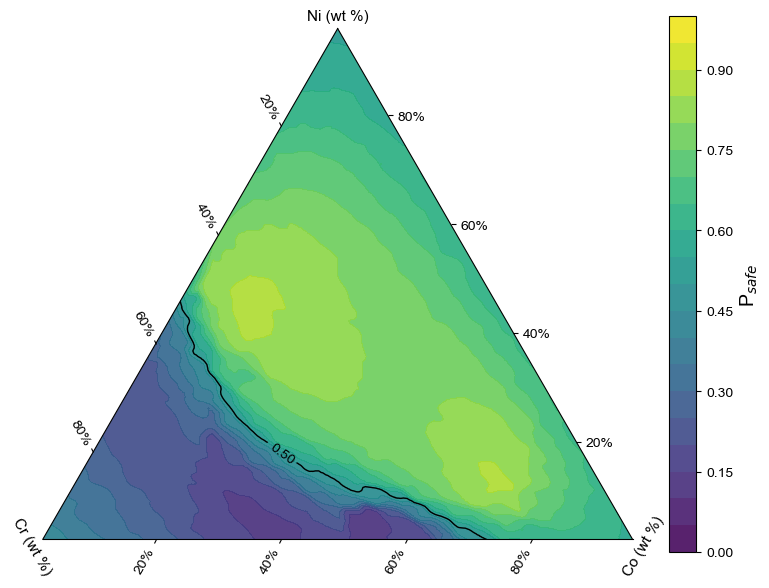

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mpltern
from matplotlib.ticker import PercentFormatter
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'

p_safe = best_gpc.predict_proba(X_candidates)[:,0]
Co = df_candidates_comp['Ni (wt %)'].values
Cr = df_candidates_comp['Cr (wt %)'].values
Ni = df_candidates_comp['Co (wt %)'].values  

n_grid = 200
co_lin = np.linspace(0,100,n_grid)
cr_lin = np.linspace(0,100,n_grid)
Co_grid, Cr_grid = np.meshgrid(co_lin, cr_lin)
Ni_grid = 100 - Co_grid - Cr_grid
mask = (Ni_grid >= 0)

P_grid = griddata(
    (Co,Cr),
    p_safe,
    (Co_grid,Cr_grid),
    method='nearest'
)
P_grid[~mask] = np.nan

sigma = 1
P_smooth = gaussian_filter(P_grid, sigma=sigma, mode='nearest')
P_smooth[~mask] = np.nan

Co_extra = Co_grid[mask]
Cr_extra = Cr_grid[mask]
Ni_extra = Ni_grid[mask]
P_extra  = P_smooth[mask]

Co_all = np.concatenate([Co,      Co_extra])
Cr_all = np.concatenate([Cr,      Cr_extra])
Ni_all = np.concatenate([Ni,      Ni_extra])
P_all  = np.concatenate([p_safe,  P_extra ])

fig = plt.figure(figsize=(8,7))
ax  = fig.add_subplot(projection='ternary', ternary_sum=100)
ax.set_tlim(2, 98)
ax.set_llim(2, 98)
ax.set_rlim(2, 98)

finite_mask = np.isfinite(P_all)
Co_all = Co_all[finite_mask]
Cr_all = Cr_all[finite_mask]
Ni_all = Ni_all[finite_mask]
P_all = P_all[finite_mask]

cf = ax.tricontourf(
    Co_all, Cr_all, Ni_all,
    P_all,
    levels=np.linspace(0,1,21),
    cmap='viridis',
    alpha=0.9
)
cs = ax.tricontour(
    Co_all, Cr_all, Ni_all,
    P_all, levels=[0.5],
    colors='k', linewidths=1
)
ax.clabel(cs, fmt='%.2f', inline=True, fontsize=10)

cbar = fig.colorbar(cf, ax=ax, shrink=0.8)
cbar.set_label('P$_{safe}$', fontsize=14)

ax.set_tlabel('Ni (wt %)', fontsize=11)
ax.set_llabel('Cr (wt %)', fontsize=11)
ax.set_rlabel('Co (wt %)', fontsize=11)
for axis in (ax.taxis, ax.laxis, ax.raxis):
    axis.set_major_formatter(PercentFormatter(100))
    for lbl in axis.get_ticklabels():
        lbl.set_fontsize(10)

plt.tight_layout()
plt.show()


## CEI vs CPI Comparison

Top-20 overlap between CEI and CPI: 16/20


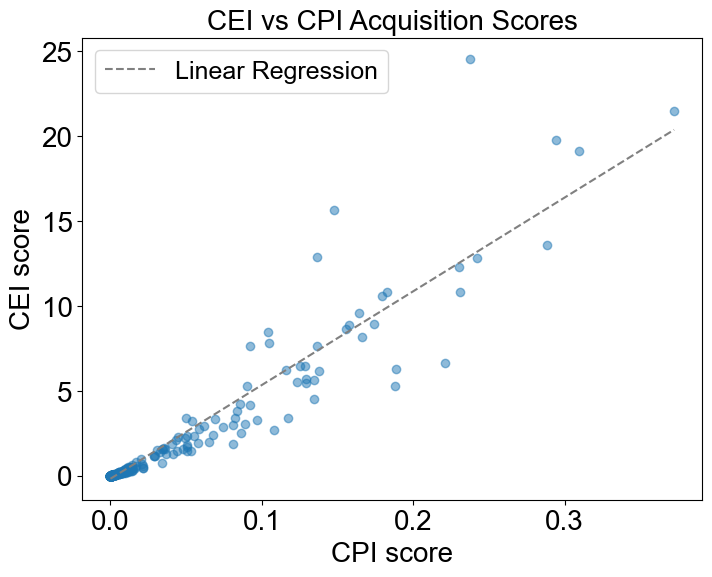

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"

# Compute CPI and CEI (p_safe ≥ 0.75)
p = 0.75
cpi = compute_cpi(X_pool, gp_reg, gp_clf, f_best, p_threshold=p)
cei = compute_cei_entropy(X_pool, gp_reg, gp_clf, f_best, p_threshold=p)

# Compare top candidates
top_n = 20
cpi_top_idx = np.argsort(cpi)[-top_n:]
cei_top_idx = np.argsort(cei)[-top_n:]
overlap = len(set(cpi_top_idx).intersection(set(cei_top_idx)))
print(f"Top-{top_n} overlap between CEI and CPI: {overlap}/{top_n}")

# Remove invalid points
mask = np.isfinite(cpi) & np.isfinite(cei)
cpi_clean = cpi[mask]
cei_clean = cei[mask]

# Fit regression line using clean data
slope, intercept = np.polyfit(cpi_clean, cei_clean, 1)
x_line = np.linspace(np.min(cpi_clean), np.max(cpi_clean), 100)
y_line = slope * x_line + intercept

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(cpi, cei, alpha=0.5)
ax.plot(x_line, y_line, '--', color='grey', label='Linear Regression')

ax.set_xlabel("CPI score", fontsize=20)
ax.set_ylabel("CEI score", fontsize=20)
ax.set_title("CEI vs CPI Acquisition Scores", fontsize=20)
ax.tick_params(axis='both', labelsize=20)
ax.legend(loc='upper left', fontsize=18)

plt.show()


Top-20 overlap between CEI and CPI: 20/20


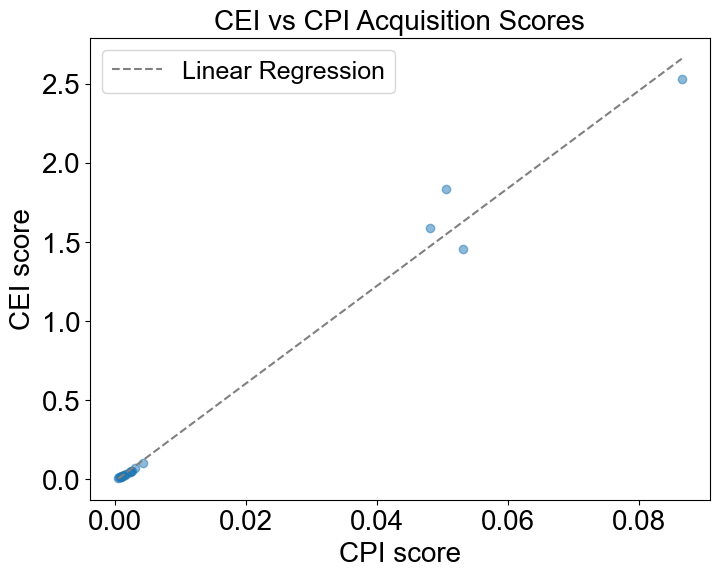

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
plt.rcParams["font.family"] = "Arial"

# Compute CPI and CEI (p_safe ≥ 0.85)
p = 0.85
cpi = compute_cpi(X_pool, gp_reg, gp_clf, f_best, p_threshold=p)
cei = compute_cei_entropy(X_pool, gp_reg, gp_clf, f_best, p_threshold=p)

# Compare top candidates
top_n = 20
cpi_top_idx = np.argsort(cpi)[-top_n:]
cei_top_idx = np.argsort(cei)[-top_n:]
overlap = len(set(cpi_top_idx).intersection(set(cei_top_idx)))
print(f"Top-{top_n} overlap between CEI and CPI: {overlap}/{top_n}")

# Remove invalid values before fitting 
mask = np.isfinite(cpi) & np.isfinite(cei)
cpi_clean = cpi[mask]
cei_clean = cei[mask]

# Fit linear regression line
slope, intercept = np.polyfit(cpi_clean, cei_clean, 1)
x_line = np.linspace(np.min(cpi_clean), np.max(cpi_clean), 100)
y_line = slope * x_line + intercept

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(cpi, cei, alpha=0.5)
ax.plot(x_line, y_line, '--', color='grey', label='Linear Regression')

ax.set_xlabel("CPI score", fontsize=20)
ax.set_ylabel("CEI score", fontsize=20)
ax.set_title("CEI vs CPI Acquisition Scores", fontsize=20)
ax.tick_params(axis='both', labelsize=20)
ax.legend(loc='upper left', fontsize=18)

plt.show()